In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import scipy.stats as st
import matplotlib.pyplot as plt
from collections import Counter
import warnings 
warnings.filterwarnings("ignore")
sns.set(color_codes = True)   
sns.set_palette(palette = 'mako', n_colors = 8)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
# Importamos el csv 
df = pd.read_csv('spotify_tracks_dataset.csv')

# Creamos una copia del data 
cp_df = df.copy()
cp_df

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [5]:
print('Number of duplicated rows: ' , len(cp_df[df.duplicated()]))

Number of duplicated rows:  0


In [6]:
cp_df.drop(['Unnamed: 0.1','Unnamed: 0'], axis=1, inplace=True)

In [14]:
## Descripcion estadistica de los datos
cp_df.describe()[1:].T.style.background_gradient(cmap='mako', axis=1)

,mean,std,min,25%,50%,75%,max
popularity,33.238535,22.305078,0.000000,17.000000,35.000000,50.000000,100.000000
duration_ms,228029.153114,107297.712645,0.000000,174066.000000,212906.000000,261506.000000,5237295.000000
danceability,0.566800,0.173542,0.000000,0.456000,0.580000,0.695000,0.985000
energy,0.641383,0.251529,0.000000,0.472000,0.685000,0.854000,1.000000
key,5.309140,3.559987,0.000000,2.000000,5.000000,8.000000,11.000000
loudness,-8.258960,5.029337,-49.531000,-10.013000,-7.004000,-5.003000,4.532000
mode,0.637553,0.480709,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,0.084652,0.105732,0.000000,0.035900,0.048900,0.084500,0.965000
acousticness,0.314910,0.332523,0.000000,0.016900,0.169000,0.598000,0.996000
instrumentalness,0.156050,0.309555,0.000000,0.000000,0.000042,0.049000,1.000000


## Tabla de correlacion 
nota: la correlacion no es una medida que involucre causalidad es por eso que solo indica la relacion 
+ -1 indica  una relacion negativa fuerte 
+ 1 indica una relacion furtemente positiva
+ 0 una debil correlacion 
   

In [32]:
df1 = ['popularity','duration_ms','danceability','energy','key','loudness'
,'mode','speechiness','acousticness','liveness','valence','tempo',
'time_signature','instrumentalness']

matrix = cp_df.corr
matrix

#matriz = cp_df[df1].corr().T.style.background_gradient(cmap='mako', axis=1)

<bound method DataFrame.corr of                       track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (

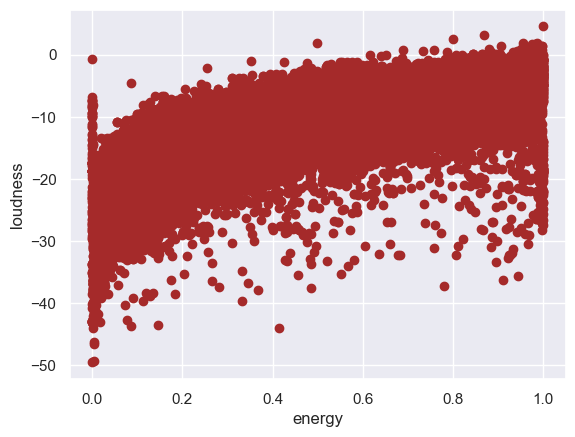

In [24]:
## Relacion entre Energy y Loudness

plt.scatter(cp_df['energy'],cp_df['loudness'],color='brown')  
plt.xlabel('energy')
plt.ylabel('loudness')
plt.show()

In [33]:
plt.matshow(matrix)

ValueError: not enough values to unpack (expected 2, got 0)